# 🌿 LAI & NDVI Crop Monitor — v3
**Autor:** Ariel Macías | Agrónomo · GIS & Remote Sensing

### Flujo de trabajo
| Celda | Descripción |
|-------|-------------|
| 0 | Parámetros de configuración |
| 1 | Inicialización GEE y dibujo del lote |
| 2 | Descarga, cálculo de índices y gráfico mensual |
| 3 | Dashboard interactivo: clic en curva → mapa con todas las capas del mes |

### Índices calculados
| Índice | Fórmula | Utilidad agronómica |
|--------|---------|---------------------|
| **NDVI** | (B8−B4)/(B8+B4) | Vigor vegetativo general |
| **LAI**  | −ln(1 − NDVI/0.95) / k | Área foliar (m²/m²), modelo Beer-Lambert |
| **EVI**  | 2.5·(B8−B4)/(B8+6·B4−7.5·B2+1) | Vigor corregido por aerosoles y suelo, no satura |
| **SAVI** | (B8−B4)/(B8+B4+L)·(1+L), L=0.5 | NDVI ajustado por suelo expuesto |
| **NDWI** | (B3−B8)/(B3+B8) | Contenido de agua en canopeo/suelo |

### Capas de visualización
| Capa | Bandas | Para qué sirve |
|------|--------|----------------|
| True Color | B4·B3·B2 | Vista natural, detecta nubes y cosecha |
| Falso Color NIR | B8·B4·B3 | Vegetación sana → rojo intenso, correlaciona con NDVI |

> **Nota sobre la imagen base:** El dashboard carga la imagen Sentinel-2 **menos nubosa** del mes (no un composite mediana), para mostrar una escena real del satélite.

In [1]:
# ============================================================
# CELDA 0 — CONFIGURACIÓN
# Editá estas variables antes de correr el notebook.
# Para mayor seguridad podés usar variables de entorno:
#   import os; GEE_PROJECT = os.environ.get('GEE_PROJECT', 'tu-proyecto')
# ============================================================

GEE_PROJECT   = 'my-project-12126-484118'   # <-- Reemplazá con tu project ID de GEE
CENTRO_LAT    = -27.48              # Latitud centro mapa inicial (Corrientes, AR)
CENTRO_LON    = -58.83              # Longitud centro mapa inicial
ZOOM_INICIAL  = 13
ANIOS_ATRAS   = 3
MAX_NUBES     = 30                  # Umbral de cobertura nubosa (%)
K_EXTINCTION  = 0.5                 # Coef. extinción Beer-Lambert (0.4–0.6 para cultivos)
SAVI_L        = 0.5                 # Factor de corrección de suelo para SAVI (0=suelo desnudo, 1=canopeo cerrado)

print("✅ Configuración cargada.")
print(f"   Proyecto GEE : {GEE_PROJECT}")
print(f"   Centro mapa  : ({CENTRO_LAT}, {CENTRO_LON})")
print(f"   Ventana      : {ANIOS_ATRAS} años | Nubes ≤ {MAX_NUBES}% | k={K_EXTINCTION} | L={SAVI_L}")

✅ Configuración cargada.
   Proyecto GEE : my-project-12126-484118
   Centro mapa  : (-27.48, -58.83)
   Ventana      : 3 años | Nubes ≤ 30% | k=0.5 | L=0.5


---
## Paso 1 · Dibujar el lote
Usá la herramienta de polígono (panel izquierdo del mapa) para delimitar tu lote y luego ejecutá la Celda 2.

In [2]:
# ============================================================
# CELDA 1 — INICIALIZACIÓN GEE Y DIBUJO DEL LOTE
# ============================================================
import matplotlib.pyplot as plt
import ee
import geemap
import pandas as pd
import numpy as np
import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display
from ipyleaflet import link

try:
    ee.Initialize(project=GEE_PROJECT)
    print("✅ Earth Engine inicializado.")
except Exception:
    print("🔑 Autenticando Earth Engine...")
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)
    print("✅ Earth Engine inicializado.")

print("\n--- PASO 1: DIBUJÁ TU LOTE ---")
print("Usá el polígono de la izquierda para dibujar. Cuando termines, ejecutá la Celda 2.")

Draw_Map = geemap.Map(center=[CENTRO_LAT, CENTRO_LON], zoom=ZOOM_INICIAL)
Draw_Map.add_basemap('SATELLITE')
display(Draw_Map)

✅ Earth Engine inicializado.

--- PASO 1: DIBUJÁ TU LOTE ---
Usá el polígono de la izquierda para dibujar. Cuando termines, ejecutá la Celda 2.


Map(center=[-27.48, -58.83], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

---
## Paso 2 · Calcular índices y graficar evolución mensual

📐 Configurando geometría del lote...
📅 Período: 2023-04-13  →  2026-04-13
⏳ Procesando imágenes satelitales (puede tardar 1–2 minutos)...
✅ 109 imágenes  →  37 meses con datos.


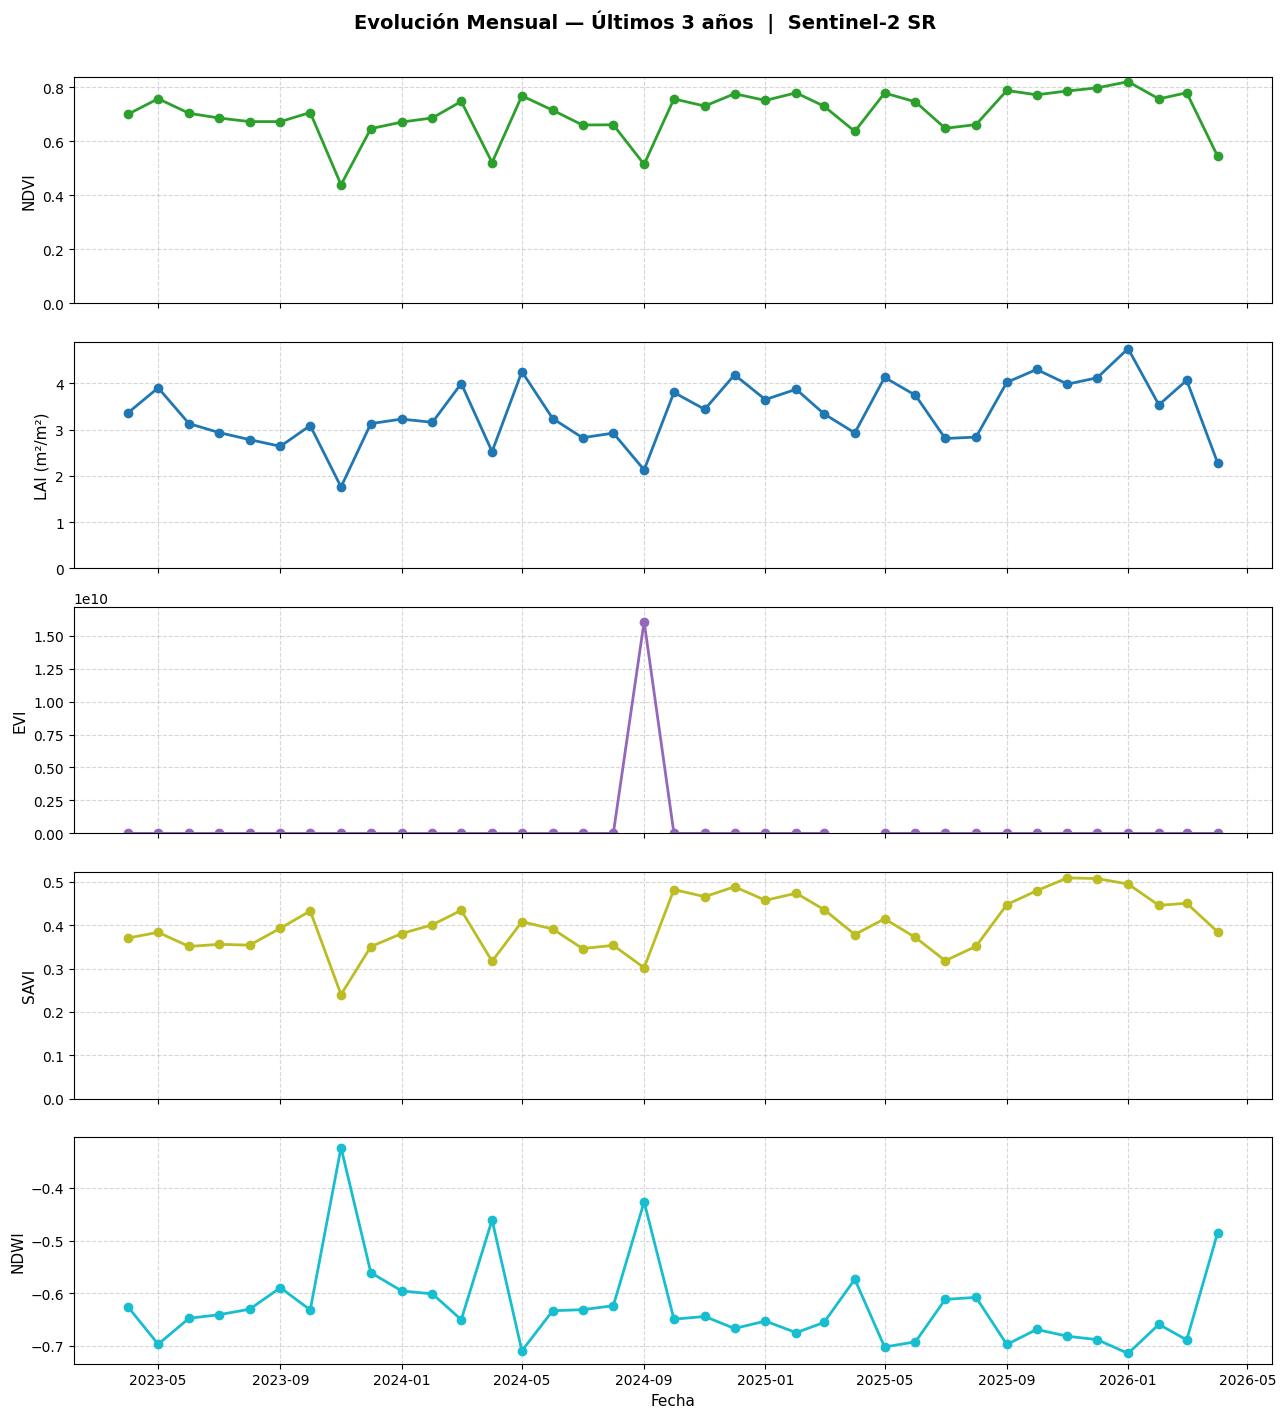

✅ Listo. Ejecutá la Celda 3 para el dashboard interactivo.


In [3]:
# ============================================================
# CELDA 2 — DESCARGA, ÍNDICES Y GRÁFICO MENSUAL
# ============================================================

# 1. Verificación del dibujo
roi = Draw_Map.user_roi
if roi is None:
    raise ValueError("⚠️ No se detectó ningún dibujo. Volvé a la Celda 1, dibujá el lote y ejecutá esta celda.")

print("📐 Configurando geometría del lote...")
roi_info  = roi.getInfo()
lote_geom = ee.Geometry(roi_info['geometry'] if 'geometry' in roi_info else roi_info)
centro    = lote_geom.centroid(maxError=1)

# 2. Ventana temporal
fecha_fin        = pd.Timestamp.today()
fecha_inicio     = fecha_fin - pd.DateOffset(years=ANIOS_ATRAS)
fecha_fin_str    = fecha_fin.strftime('%Y-%m-%d')
fecha_inicio_str = fecha_inicio.strftime('%Y-%m-%d')
print(f"📅 Período: {fecha_inicio_str}  →  {fecha_fin_str}")

# 3. Función central de índices
def add_indices(image):
    # --- NDVI ---
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

    # --- LAI (Beer-Lambert) ---
    ndvi_c = ndvi.max(ee.Image(0)).min(ee.Image(0.95))
    lai = (ee.Image(1)
             .subtract(ndvi_c.divide(0.95))
             .log()
             .multiply(-1.0 / K_EXTINCTION)
             .max(0)
             .rename('LAI'))

    # --- EVI (Enhanced Vegetation Index) ---
    # 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    # Reflectancias en S2 SR están en rango 0–10000 → dividimos por 10000
    nir  = image.select('B8').divide(10000)
    red  = image.select('B4').divide(10000)
    blue = image.select('B2').divide(10000)
    evi = (nir.subtract(red)
              .multiply(2.5)
              .divide(nir.add(red.multiply(6))
                         .subtract(blue.multiply(7.5))
                         .add(1))
              .rename('EVI'))

    # --- SAVI (Soil Adjusted Vegetation Index) ---
    # (NIR - Red) / (NIR + Red + L) * (1 + L)
    savi = (nir.subtract(red)
               .divide(nir.add(red).add(SAVI_L))
               .multiply(1 + SAVI_L)
               .rename('SAVI'))

    # --- NDWI (Normalized Difference Water Index — McFeeters) ---
    # (Green - NIR) / (Green + NIR)
    ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')

    return (image
            .addBands([ndvi, lai, evi, savi, ndwi])
            .copyProperties(image, ['system:time_start']))

# 4. Colección S2 SR Harmonized
s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(lote_geom)
          .filterDate(fecha_inicio_str, fecha_fin_str)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', MAX_NUBES))
          .map(add_indices))

# 5. Extracción de estadísticas por imagen
def extract_stats(image):
    mean_dict = image.select(['NDVI', 'LAI', 'EVI', 'SAVI', 'NDWI']).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=lote_geom,
        scale=10,
        maxPixels=1e9
    )
    date = ee.Date(image.get('system:time_start')).format('YYYY-MM-dd')
    return ee.Feature(None, {
        'date' : date,
        'NDVI' : mean_dict.get('NDVI'),
        'LAI'  : mean_dict.get('LAI'),
        'EVI'  : mean_dict.get('EVI'),
        'SAVI' : mean_dict.get('SAVI'),
        'NDWI' : mean_dict.get('NDWI')
    })

print("⏳ Procesando imágenes satelitales (puede tardar 1–2 minutos)...")
ts_list = ee.FeatureCollection(s2_col.map(extract_stats)).getInfo()['features']

# 6. DataFrame mensual
datos = [
    {'Fecha': pd.to_datetime(f['properties']['date']),
     'NDVI' : f['properties'].get('NDVI'),
     'LAI'  : f['properties'].get('LAI'),
     'EVI'  : f['properties'].get('EVI'),
     'SAVI' : f['properties'].get('SAVI'),
     'NDWI' : f['properties'].get('NDWI')}
    for f in ts_list
    if f['properties'].get('NDVI') is not None
]

df = pd.DataFrame(datos).set_index('Fecha')
df_mensual = df.resample('MS').mean().dropna()
print(f"✅ {len(df)} imágenes  →  {len(df_mensual)} meses con datos.")

# 7. Gráfico multipanel
indices_plot = {
    'NDVI' : ('tab:green',  'NDVI'),
    'LAI'  : ('tab:blue',   'LAI (m²/m²)'),
    'EVI'  : ('tab:purple', 'EVI'),
    'SAVI' : ('tab:olive',  'SAVI'),
    'NDWI' : ('tab:cyan',   'NDWI'),
}

fig, axes = plt.subplots(len(indices_plot), 1, figsize=(13, 14), sharex=True)
fig.suptitle(f'Evolución Mensual — Últimos {ANIOS_ATRAS} años  |  Sentinel-2 SR',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (col, (color, label)) in zip(axes, indices_plot.items()):
    ax.plot(df_mensual.index, df_mensual[col],
            marker='o', color=color, linewidth=2)
    ax.set_ylabel(label, fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(bottom=0 if col != 'NDWI' else None)

axes[-1].set_xlabel('Fecha', fontsize=11)
fig.tight_layout()
plt.show()

# Coordenadas del centro para el dashboard
centro_coords = centro.getInfo()['coordinates']
centro_mapa   = [centro_coords[1], centro_coords[0]]
print("✅ Listo. Ejecutá la Celda 3 para el dashboard interactivo.")

---
## Paso 3 · Dashboard interactivo
Hacé clic en cualquier punto de la curva NDVI para cargar **todas las capas** de ese mes en el mapa:
True Color · Falso Color NIR · NDVI · LAI · EVI · SAVI · NDWI

In [ ]:
# ============================================================
# CELDA 3 — DASHBOARD INTERACTIVO COMPLETO
# ============================================================

# --- Paletas de visualización ---
vis_true_color  = {'min': 0,   'max': 3000, 'bands': ['B4', 'B3', 'B2']}         # RGB natural
vis_false_color = {'min': 0,   'max': 5000, 'bands': ['B8', 'B4', 'B3']}         # NIR-R-G
vis_ndvi        = {'min': 0.1, 'max': 0.8,  'palette': ['red', 'yellow', 'green']}
vis_lai         = {'min': 0,   'max': 6,    'palette': ['#f7fbff','#c6dbef','#6baed6','#2171b5','#08306b']}
vis_evi         = {'min': 0,   'max': 0.8,  'palette': ['#ffffe5','#78c679','#004529']}
vis_savi        = {'min': 0,   'max': 0.7,  'palette': ['#fff7bc','#d9f0a3','#238443']}
vis_ndwi        = {'min': -0.5,'max': 0.5,  'palette': ['#d7191c','#ffffbf','#2c7bb6']}  # seco → húmedo

# Todas las capas dinámicas que el callback va a manejar
CAPAS_DINAMICAS = ('True Color', 'Falso Color NIR',
                   'NDVI', 'LAI', 'EVI', 'SAVI', 'NDWI')

# --- Mapa base ---
interactive_map = geemap.Map(center=centro_mapa, zoom=15)
interactive_map.add_basemap('SATELLITE')
interactive_map.addLayer(
    ee.Image().paint(lote_geom, 0, 2),
    {'palette': 'red'}, 'Límites del Lote'
)

# --- Gráfico interactivo NDVI ---
fechas_str = df_mensual.index.strftime('%Y-%m')

fig_widget = go.FigureWidget()
fig_widget.add_trace(go.Scatter(
    x=fechas_str,
    y=df_mensual['NDVI'],
    mode='lines+markers',
    name='NDVI',
    line=dict(color='green', width=2),
    marker=dict(size=10, symbol='circle', line=dict(color='darkgreen', width=1))
))
fig_widget.update_layout(
    title='Curva Fenológica NDVI — Hacé clic en un punto para cargar todas las capas del mes',
    xaxis_title='Mes',
    yaxis=dict(title='NDVI Promedio Mensual', range=[0, 1]),
    hovermode='closest',
    height=350,
    margin=dict(l=40, r=40, t=50, b=40),
    dragmode=False
)

out = widgets.Output()

# --- Callback principal ---
@out.capture(clear_output=True)
def update_map_on_click(trace, points, selector):
    if not points.point_inds:
        return

    idx           = points.point_inds[0]
    selected_date = df_mensual.index[idx]
    start_str     = selected_date.strftime('%Y-%m-01')
    end_str       = (selected_date + pd.offsets.MonthEnd(1)).strftime('%Y-%m-%d')
    mes_label     = selected_date.strftime('%Y-%m')

    print(f"🗓️  Cargando capas para: {mes_label} ...")

    try:
        # 1. Eliminar capas dinámicas anteriores, preservar límite y basemap
        capas_a_borrar = [
            c for c in interactive_map.layers
            if any(getattr(c, 'name', '').startswith(p) for p in CAPAS_DINAMICAS)
        ]
        for c in capas_a_borrar:
            interactive_map.remove_layer(c)

        # 2. Imagen menos nubosa del mes (escena real, no composite mediana)
        mes_col   = s2_col.filterDate(start_str, end_str)
        best_img  = mes_col.sort('CLOUDY_PIXEL_PERCENTAGE').first().clip(lote_geom)

        # 3. Composite mediana para los índices (más robusto ante nubes residuales)
        mediana   = mes_col.median().clip(lote_geom)

        # 4. Agregar capas al mapa (orden: de abajo hacia arriba)
        interactive_map.addLayer(best_img,            vis_true_color,  f'True Color ({mes_label})')
        interactive_map.addLayer(best_img,            vis_false_color, f'Falso Color NIR ({mes_label})')
        interactive_map.addLayer(mediana.select('NDVI'), vis_ndvi,     f'NDVI ({mes_label})')
        interactive_map.addLayer(mediana.select('LAI'),  vis_lai,      f'LAI ({mes_label})')
        interactive_map.addLayer(mediana.select('EVI'),  vis_evi,      f'EVI ({mes_label})')
        interactive_map.addLayer(mediana.select('SAVI'), vis_savi,     f'SAVI ({mes_label})')
        interactive_map.addLayer(mediana.select('NDWI'), vis_ndwi,     f'NDWI ({mes_label})')

        # 5. Resumen de valores del mes
        row = df_mensual.loc[selected_date]
        print(f"   NDVI : {row['NDVI']:.3f}")
        print(f"   LAI  : {row['LAI']:.3f}  m²/m²")
        print(f"   EVI  : {row['EVI']:.3f}")
        print(f"   SAVI : {row['SAVI']:.3f}")
        print(f"   NDWI : {row['NDWI']:.3f}")
        print("✅ Capas cargadas. Usá el panel de capas del mapa para alternarlas.")

    except Exception as e:
        print(f"❌ Error: {e}")

# Asignar callback
fig_widget.data[0].on_click(update_map_on_click)

# Desplegar dashboard
display(widgets.VBox([
    fig_widget,
    out,
    interactive_map
]))

    'data': [{'line': {'color': 'green', 'width': 2},
              'marker': {'…